In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from IPython.display import display

In [2]:
# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# If your JSON is an array, not an object with "data" key:
df = pd.DataFrame(data)
# If label is boolean, you may want to convert it to int or str
df['label'] = df['label'].astype(int)  # Uncomment if needed

X = df['text']
y = df['label']

# show head
print(df.head())

                                                text  label
0                        mari ramai ernia widyatmoko      0
1         mantap linkbonbon berani kasi menang orang      1
2  wd coy mahaslot royal bro jt kasih nya hahah m...      1
3                     gacor parah ey mantap mahaslot      1
4  wajah materialistis udah klaim freebet pepe kl...      1


In [7]:
# Stratified K-Fold Cross Validation
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    fold += 1


# Calculate mean metrics
def mean_metric(metric):
    return np.mean([fold[metric]['f1-score'] for fold in fold_reports])

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}

for label in labels:
    mean_results[label] = {m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics}

mean_results['accuracy'] = np.mean([fold['accuracy'] for fold in fold_reports])
mean_results['macro avg'] = {m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics}
mean_results['weighted avg'] = {m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics}
print("Mean metrics per class across folds:")
print(mean_results)
print("Mean accuracy across folds:", mean_results['accuracy'])
print("Stratified 10-Fold CV Accuracy scores:", cv_scores)
print("Confusion Matrix:\n", confusion_matrix(all_y_true, all_y_pred))


Fold 1: 0.9397697077059345


,precision,recall,f1-score,support
0,0.939002,0.935543,0.937269,543.00000
1,0.940476,0.943686,0.942078,586.00000
accuracy,0.939770,0.939770,0.939770,0.93977
macro avg,0.939739,0.939615,0.939674,1129.00000
weighted avg,0.939767,0.939770,0.939765,1129.00000


Fold 1: 0.9397697077059345


,precision,recall,f1-score,support
0,0.939002,0.935543,0.937269,543.00000
1,0.940476,0.943686,0.942078,586.00000
accuracy,0.939770,0.939770,0.939770,0.93977
macro avg,0.939739,0.939615,0.939674,1129.00000
weighted avg,0.939767,0.939770,0.939765,1129.00000


Fold 2: 0.933569530558016


...

,precision,recall,f1-score,support
0,0.906810,0.931860,0.919164,543.000000
1,0.935201,0.911263,0.923077,586.000000
accuracy,0.921169,0.921169,0.921169,0.921169
macro avg,0.921006,0.921561,0.921121,1129.000000
weighted avg,0.921546,0.921169,0.921195,1129.000000


Fold 10: 0.9255978742249779


,precision,recall,f1-score,support
0,0.921101,0.924494,0.922794,543.000000
1,0.929795,0.926621,0.928205,586.000000
accuracy,0.925598,0.925598,0.925598,0.925598
macro avg,0.925448,0.925557,0.925500,1129.000000
weighted avg,0.925613,0.925598,0.925603,1129.000000


,precision,recall,f1-score
0,0.926553,0.926151,0.926227
1,0.931773,0.931741,0.931652
accuracy,0.929052,0.929052,0.929052
macro avg,0.929163,0.928946,0.928939
weighted avg,0.929262,0.929052,0.929043


Mean metrics per class across folds:
              precision    recall  f1-score
0              0.926553  0.926151  0.926227
1              0.931773  0.931741  0.931652
accuracy       0.929052  0.929052  0.929052
macro avg      0.929163  0.928946  0.928939
weighted avg   0.929262  0.929052  0.929043
Mean accuracy across folds: 0.9290522586359611
Stratified 10-Fold CV Accuracy scores: [0.9397697077059345, 0.933569530558016, 0.9362267493356953, 0.9264836138175376, 0.9247121346324181, 0.9309123117803366, 0.9220549158547388, 0.9300265721877768, 0.9211691762621789, 0.9255978742249779]
Confusion Matrix:
 [[5029  401]
 [ 400 5460]]


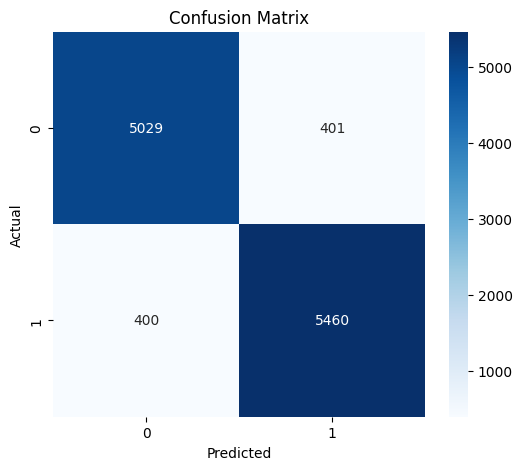

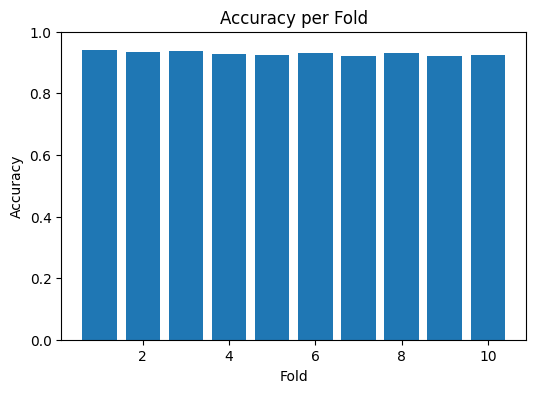

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ...existing code...

# After printing the confusion matrix and classification report:
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy scores bar plot
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(cv_scores) + 1), cv_scores)
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per Fold')
plt.show()

In [ ]:

# Optionally, train on all data for deployment
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_tfidf, y)

# Save the model and vectorizer for future use
joblib.dump(model, 'rf_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated score: 0.935093785781455


,precision,recall,f1-score,support
0,0.996524,0.998607,0.997564,5742.000000
1,0.998682,0.996712,0.997696,6083.000000
accuracy,0.997632,0.997632,0.997632,0.997632
macro avg,0.997603,0.997659,0.997630,11825.000000
weighted avg,0.997634,0.997632,0.997632,11825.000000


Confusion Matrix:
 [[5734    8]
 [  20 6063]]


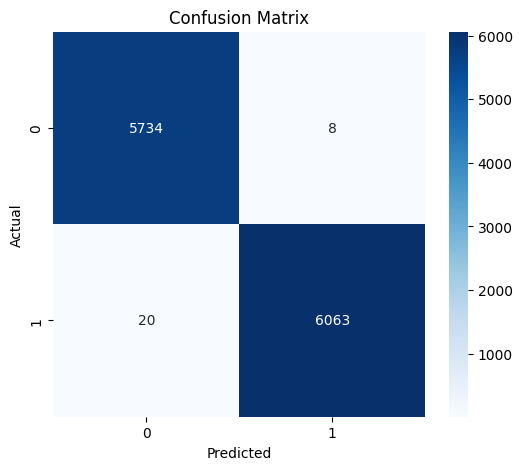

['result/tfidf_vectorizer.pkl']

In [13]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data from JSON file (array of objects)
with open('fetched_data_final.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# TF-IDF vectorization (fit on all data for search)
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Choose number of splits (5 or 10)
n_splits = 10  # Change to 5 or 10 as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

# Grid Search with StratifiedKFold
search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

search.fit(X_tfidf, y)

print("Best parameters:", search.best_params_)
print("Best cross-validated score:", search.best_score_)

# Evaluate on all data using best estimator
y_pred = search.best_estimator_.predict(X_tfidf)
# print("\nClassification Report:\n", classification_report(y, y_pred, digits=4, output_dict=True))
display(pd.DataFrame(classification_report(y, y_pred, digits=4, output_dict=True)).transpose())
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save model and vectorizer for future use
joblib.dump(search.best_estimator_, 'result/rf_model_best.pkl')
joblib.dump(vectorizer, 'result/tfidf_vectorizer.pkl')